#### =========================
#### IMPORT LIBRARIES
#### =========================

In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import mlflow
import mlflow.sklearn


#### =========================
#### LOAD DATA
#### =========================

In [58]:
df = pd.read_csv("london_weather.csv")
df.head(15)

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0
5,19790106,5.0,3.8,39.0,8.3,-0.5,-6.6,0.7,102780.0,1.0
6,19790107,8.0,0.0,13.0,8.5,1.5,-5.3,5.2,102520.0,0.0
7,19790108,8.0,0.1,15.0,5.8,6.9,5.3,0.8,101870.0,0.0
8,19790109,4.0,5.8,50.0,5.2,3.7,1.6,7.2,101170.0,0.0
9,19790110,7.0,1.9,30.0,4.9,3.3,1.4,2.1,98700.0,0.0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       15322 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


Remove unnecessary columns

In [60]:
possible_drop_cols = ["date"]
for col in possible_drop_cols:
    if col in df.columns:
        df = df.drop(columns=col)

Drop rows where target is missing
- target column = mean_temp

In [61]:
df = df.dropna(subset=["mean_temp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15305 entries, 0 to 15340
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cloud_cover       15286 non-null  float64
 1   sunshine          15305 non-null  float64
 2   global_radiation  15286 non-null  float64
 3   max_temp          15305 non-null  float64
 4   mean_temp         15305 non-null  float64
 5   min_temp          15305 non-null  float64
 6   precipitation     15303 non-null  float64
 7   pressure          15301 non-null  float64
 8   snow_depth        13881 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [62]:
print("\nStatistical Summary")
df.describe()


Statistical Summary


,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,15286.000000,15305.000000,15286.000000,15305.000000,15305.000000,15305.000000,15303.000000,15301.000000,13881.000000
mean,5.267107,4.352382,118.758864,15.386893,11.475511,7.556576,1.669352,101536.896281,0.038038
std,2.070059,4.028954,88.890133,6.555723,5.729709,5.326749,3.739994,1049.725819,0.546004
min,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


In [79]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64


In [64]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")


Duplicate Rows: 0


In [65]:
# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns
num_cols

Index(['cloud_cover', 'sunshine', 'global_radiation', 'max_temp', 'mean_temp',
       'min_temp', 'precipitation', 'pressure', 'snow_depth'],
      dtype='object')

In [66]:
# Categorical Columns
cat_cols = df.select_dtypes(exclude=np.number).columns
cat_cols

Index([], dtype='object')

In [67]:
# Fill numerical missing values with median
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])


In [68]:
# ============================================
# OUTLIER DETECTION & REMOVAL (IQR METHOD)
# ============================================

def remove_outliers_iqr(data, columns):
    
    for col in columns:
        
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data = data[
            (data[col] >= lower) &
            (data[col] <= upper)
        ]
        
    return data

df = remove_outliers_iqr(df, num_cols)

print("\nDataset Shape After Outlier Removal:", df.shape)



Dataset Shape After Outlier Removal: (12831, 9)


In [69]:
# ============================================
# FEATURE SCALING
# ============================================

scaler = StandardScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])


NameError: name 'StandardScaler' is not defined

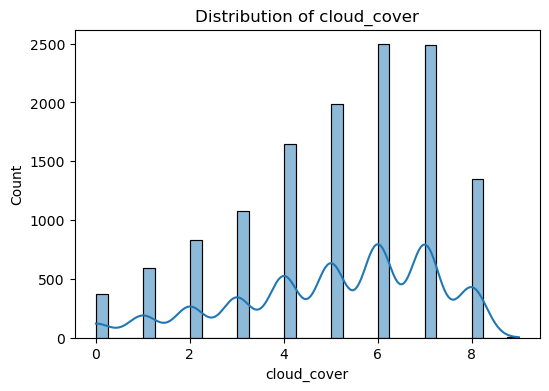

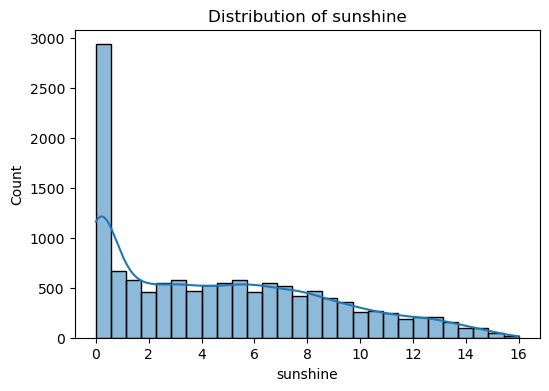

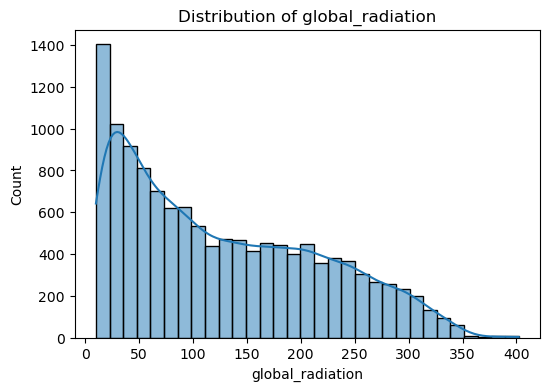

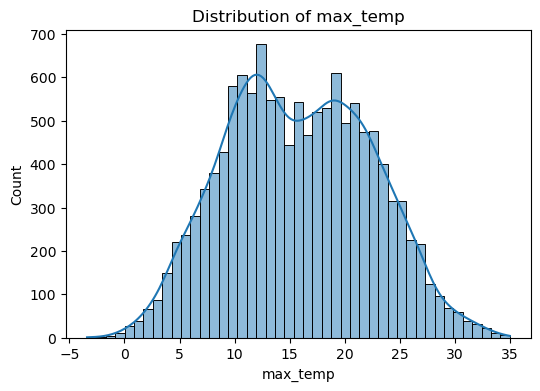

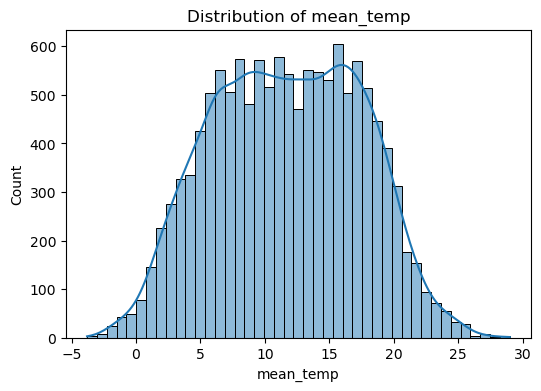

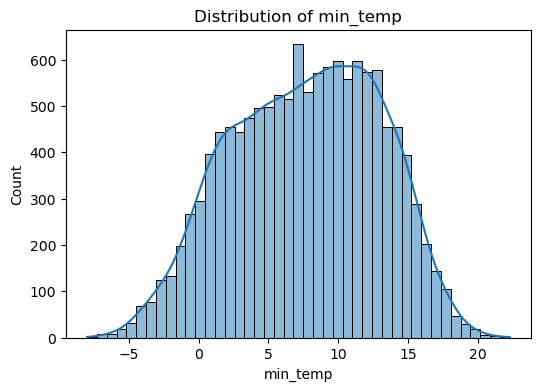

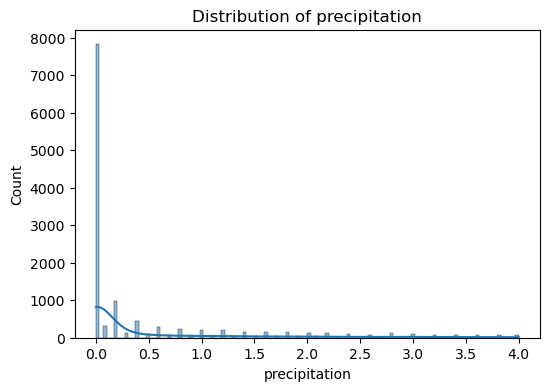

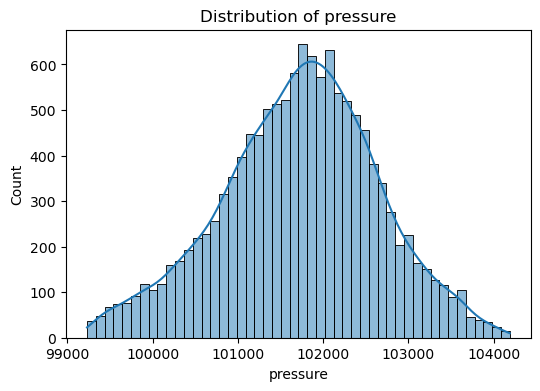

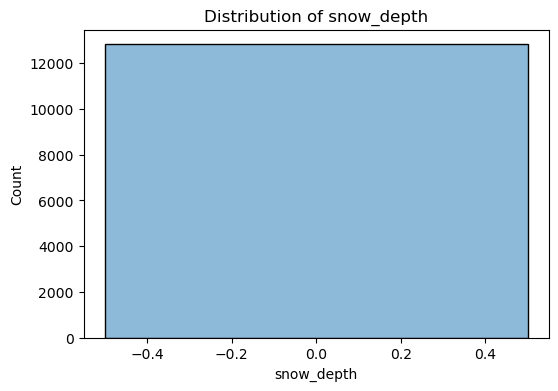

In [ ]:
# ============================================
# UNIVARIATE ANALYSIS
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()


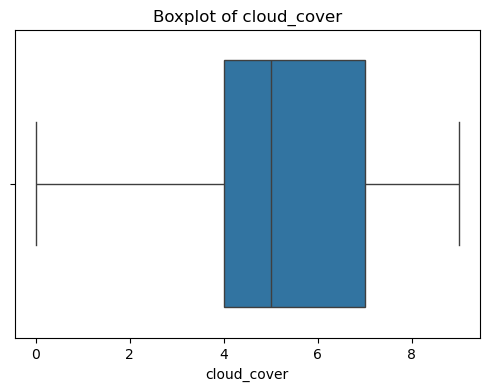

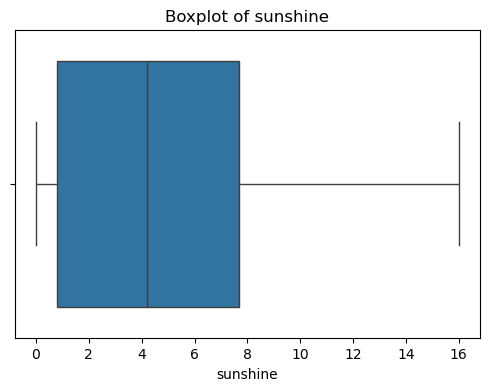

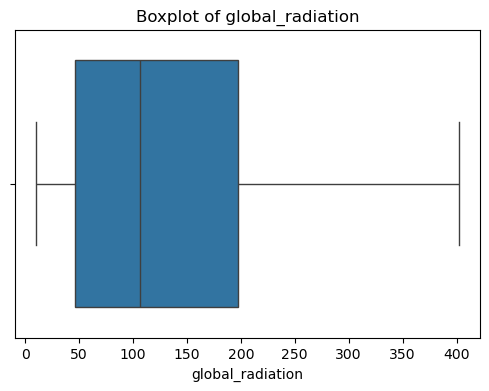

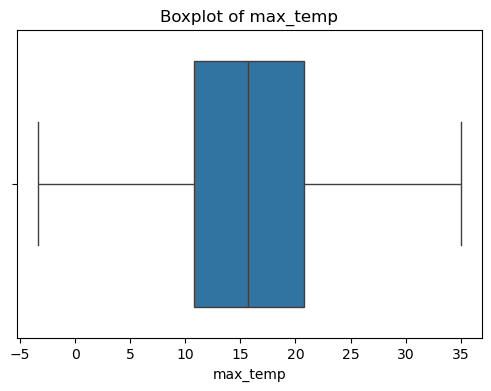

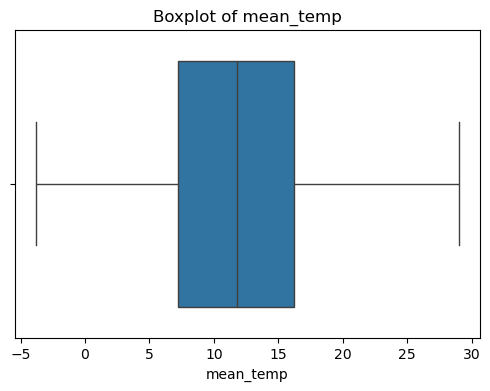

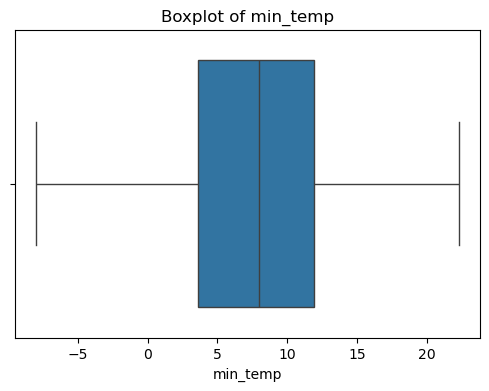

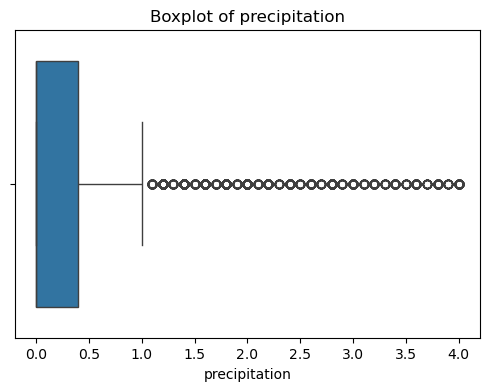

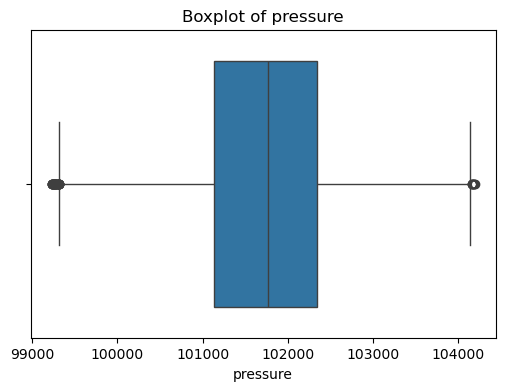

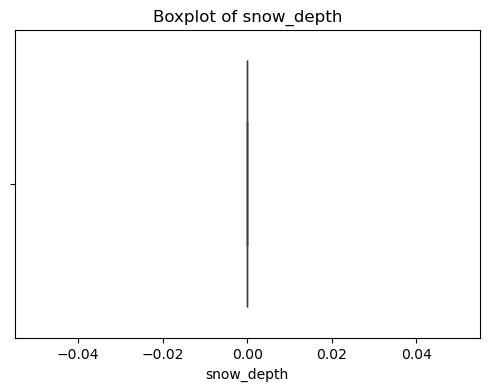

In [ ]:
# ============================================
# BOXPLOT FOR OUTLIERS
# ============================================

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()


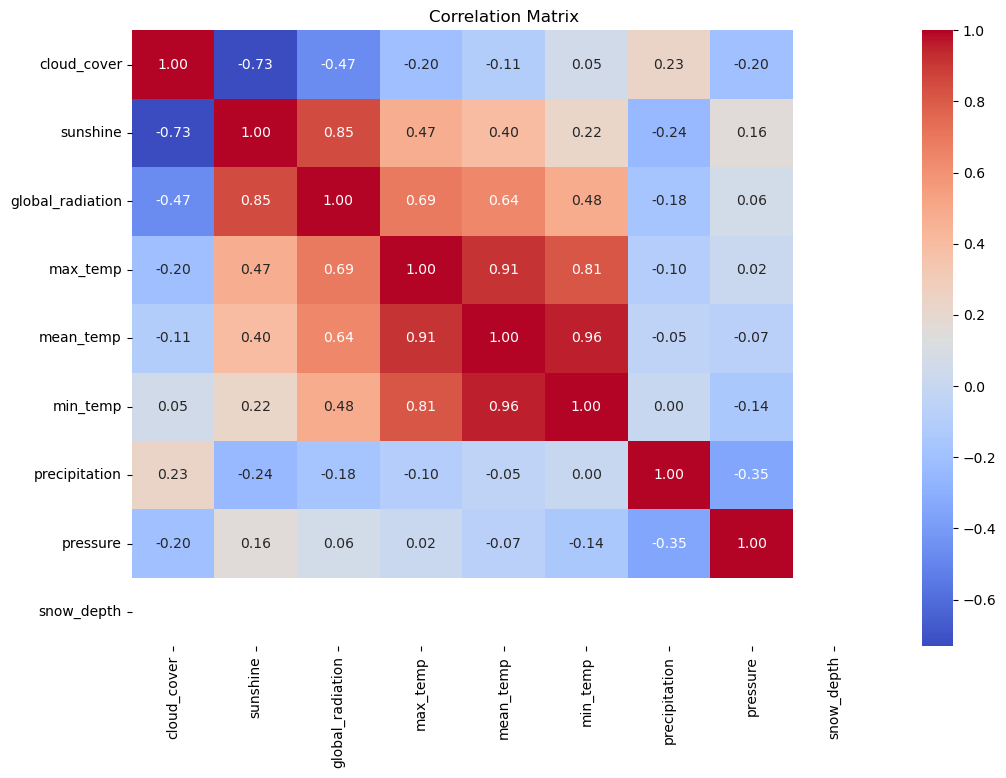

In [ ]:
# ============================================
# CORRELATION MATRIX
# ============================================

plt.figure(figsize=(12,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

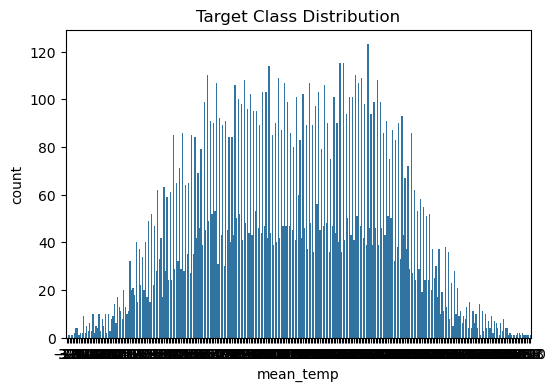

In [ ]:
# ============================================
# TARGET VARIABLE ANALYSIS
# ============================================

target_col = "mean_temp"   # Replace with your target column

if target_col in df.columns:
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(x=df[target_col])
    
    plt.title("Target Class Distribution")
    
    plt.show()

In [ ]:
# ============================================
# CHECK CLASS IMBALANCE
# ============================================

if target_col in df.columns:
    
    print("\nTarget Value Counts")
    print(df[target_col].value_counts())




Target Value Counts
mean_temp
 16.6    123
 15.0    115
 14.8    115
 10.2    114
 15.8    110
        ... 
 26.3      1
-2.1       1
 28.7      1
 28.8      1
 23.9      1
Name: count, Length: 301, dtype: int64


TARGET DISTRIBUTION

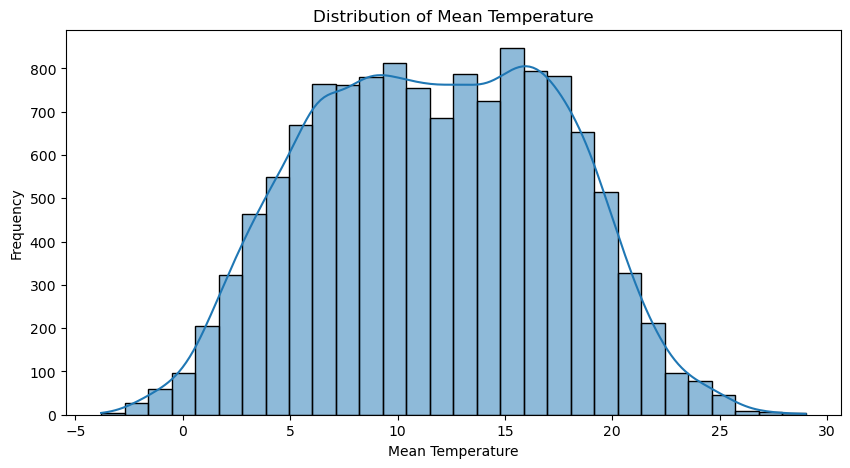

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(df['mean_temp'], bins=30, kde=True)

plt.title("Distribution of Mean Temperature")
plt.xlabel("Mean Temperature")
plt.ylabel("Frequency")

plt.show()

CHECK SKEWNESS

In [ ]:
print("Skewness:", df['mean_temp'].skew())

Skewness: -0.015024902955801951


BOXPLOT FOR OUTLIERS

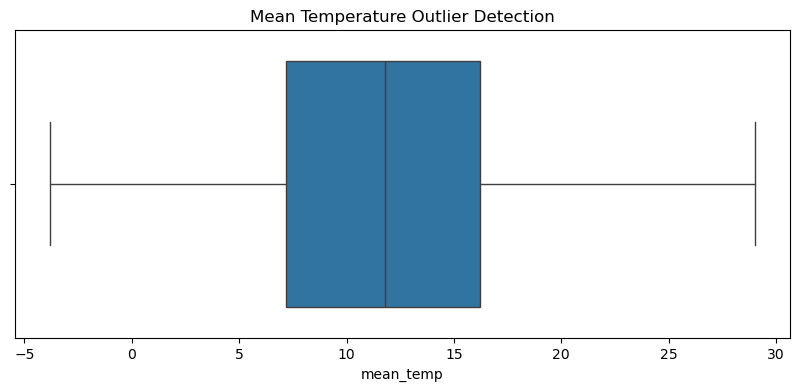

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['mean_temp'])

plt.title("Mean Temperature Outlier Detection")

plt.show()

TARGET STATISTICS

In [ ]:
print(df['mean_temp'].describe())

count    12831.000000
mean        11.728330
std          5.719829
min         -3.800000
25%          7.200000
50%         11.800000
75%         16.200000
max         29.000000
Name: mean_temp, dtype: float64


CHECK TARGET COVERAGE

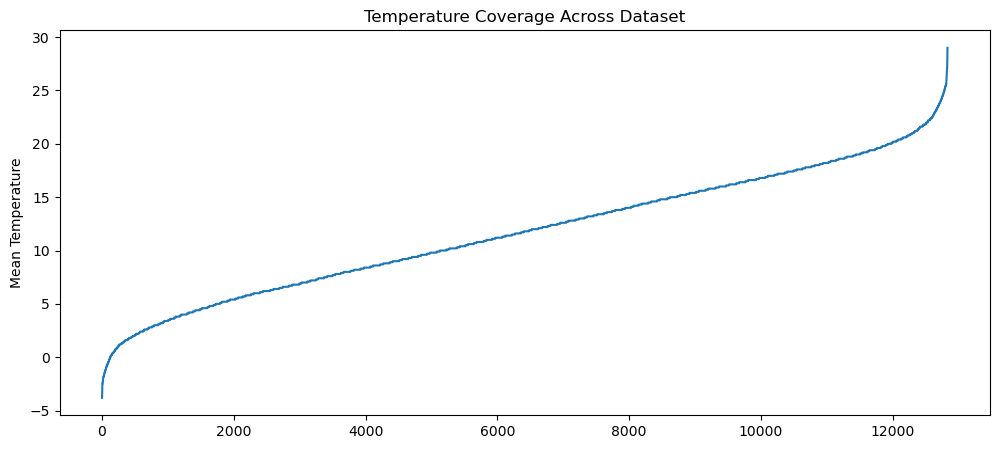

In [ ]:
plt.figure(figsize=(12,5))

df['mean_temp'].sort_values().reset_index(drop=True).plot()

plt.title("Temperature Coverage Across Dataset")

plt.ylabel("Mean Temperature")

plt.show()

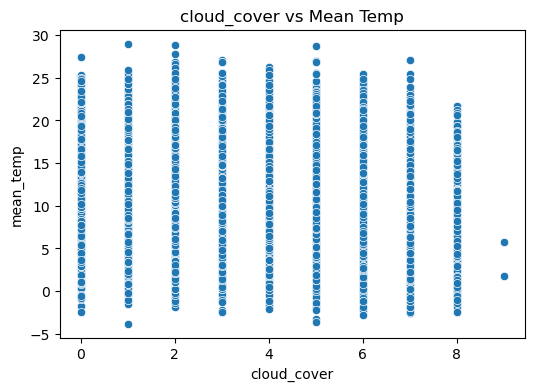

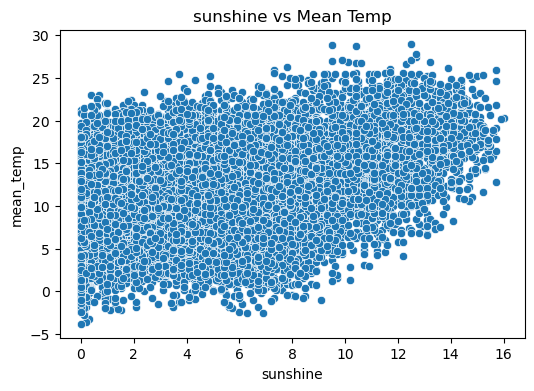

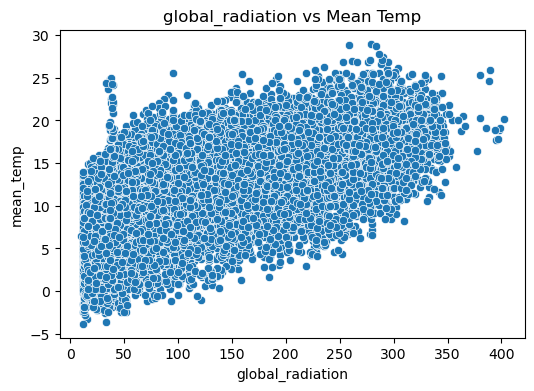

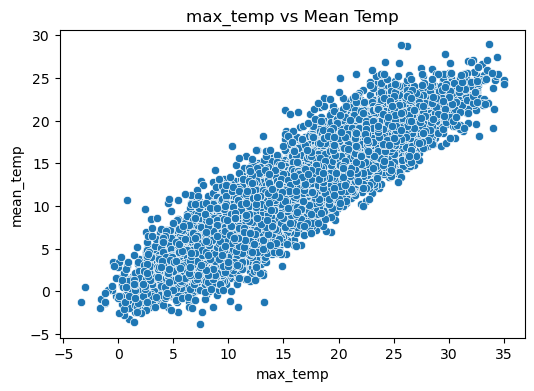

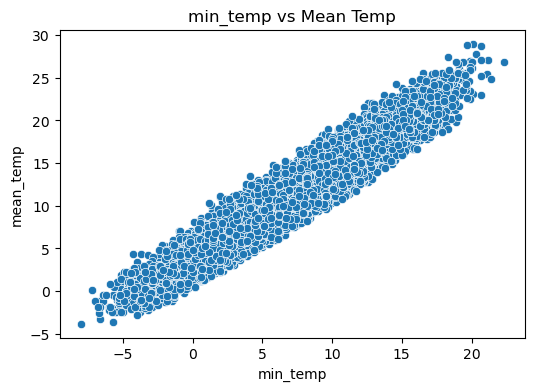

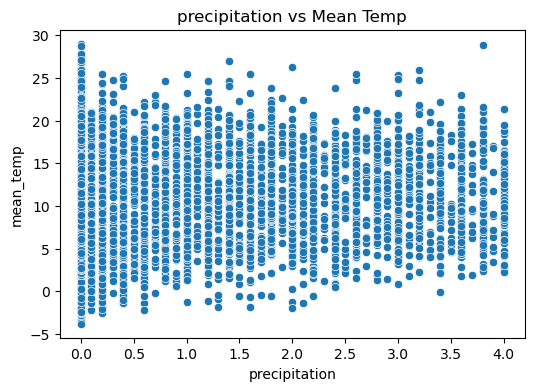

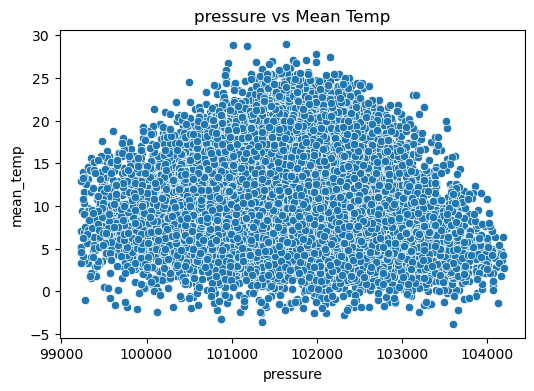

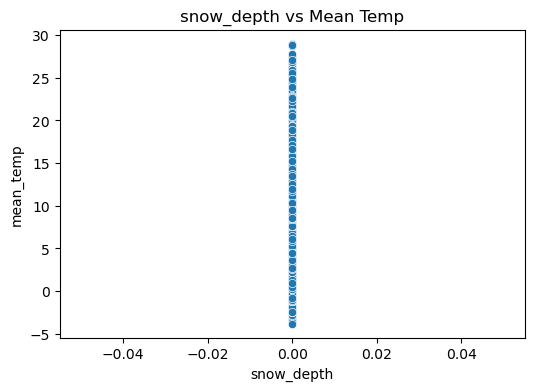

In [ ]:
numerical_cols = df.select_dtypes(include='number').columns

for col in numerical_cols:
    
    if col != 'mean_temp':
        
        plt.figure(figsize=(6,4))
        
        sns.scatterplot(
            x=df[col],
            y=df['mean_temp']
        )
        
        plt.title(f"{col} vs Mean Temp")
        
        plt.show()

CORRELATION WITH TARGET

In [ ]:
corr = df.corr(numeric_only=True)

target_corr = corr['mean_temp'].sort_values(ascending=False)

print(target_corr)

mean_temp           1.000000
min_temp            0.955355
max_temp            0.914049
global_radiation    0.638509
sunshine            0.403750
precipitation      -0.048205
pressure           -0.074617
cloud_cover        -0.108534
snow_depth               NaN
Name: mean_temp, dtype: float64


In [ ]:
# =========================
# FEATURES & TARGET
# =========================
X = df.drop(columns=["mean_temp"])
y = df["mean_temp"]


In [ ]:
# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# =========================
# MLFLOW EXPERIMENT SETUP
# =========================
mlflow.set_experiment("London_Temperature_Prediction")


2026/05/15 18:00:02 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 18:00:02 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 18:00:08 INFO mlflow.tracking.fluent: Experiment with name 'London_Temperature_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:c:/Users/USER/Documents/FelicityTech/Machine-Learning-Engineer/Projects/London '
 'Weather Prediction/mlruns/1'), creation_time=1778864408897, experiment_id='1', last_update_time=1778864408897, lifecycle_stage='active', name='London_Temperature_Prediction', tags={}, trace_location=None, workspace='default'>

In [70]:
# =========================
# HYPERPARAMETER SEARCH
# =========================
# Try multiple RandomForest settings
param_grid = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 15},
    {"n_estimators": 300, "max_depth": 20},
    {"n_estimators": 500, "max_depth": None},
]

best_rmse = float("inf")
best_model = None

In [74]:


for params in param_grid:

    with mlflow.start_run():

        # Build pipeline
        model_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=params["n_estimators"],
                    max_depth=params["max_depth"],
                    random_state=42,
                    n_jobs=-1
                )
            )
        ])

        # Train model
        model_pipeline.fit(X_train, y_train)

        # Predictions
        preds = model_pipeline.predict(X_test)

        # RMSE
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # =========================
        # LOG PARAMETERS
        # =========================
        mlflow.log_param("n_estimators", params["n_estimators"])
        mlflow.log_param("max_depth", params["max_depth"])

        # =========================
        # LOG METRICS
        # IMPORTANT: include 'rmse' in metric name
        # =========================
        mlflow.log_metric("rmse", rmse)

        # =========================
        # LOG MODEL
        # =========================
        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model"
        )

        print(f"Params: {params} -> RMSE: {rmse:.4f}")

        # Track best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model_pipeline

# =========================
# FINAL BEST SCORE
# =========================
print("\nBest RMSE:", best_rmse)

if best_rmse <= 3:
    print("Target achieved: RMSE <= 3")
else:
    print("Target NOT achieved yet. Try feature engineering or more tuning.")

# =========================
# SEARCH ALL RUNS
# =========================
experiment = mlflow.get_experiment_by_name("London_Temperature_Prediction")

experiment_results = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# Display results
print(experiment_results[[
    "run_id",
    "metrics.rmse",
    "params.n_estimators",
    "params.max_depth"
]])


2026/05/15 18:12:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 18:12:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Params: {'n_estimators': 100, 'max_depth': 10} -> RMSE: 0.8643


2026/05/15 18:14:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 18:14:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Params: {'n_estimators': 200, 'max_depth': 15} -> RMSE: 0.8711


2026/05/15 18:14:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 18:14:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Params: {'n_estimators': 300, 'max_depth': 20} -> RMSE: 0.8706


2026/05/15 18:16:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 18:16:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Params: {'n_estimators': 500, 'max_depth': None} -> RMSE: 0.8717

Best RMSE: 0.8643033964754079
Target achieved: RMSE <= 3
                              run_id  ...  params.max_depth
0   85e80c2197c241fca32b09a757b0e266  ...              None
1   67000652d63641dd9d0f21d00b66bfbb  ...                20
2   7be458e9e4914d549e70e150d04c54ba  ...                15
3   f40f178f87c5440e83f4455e83d25bcf  ...                10
4   5fa22c30e76c47d8be10ffdc587d7ca9  ...              None
5   1153d74e9ac04de9945ecafa39aada1d  ...              None
6   7a01fa3b40cc4dbea6d0aca7914fefae  ...              None
7   5f2c9f1421e3425d8f72a5749345627e  ...              None
8   9a22cf71fd854322ba0eed81f5c72248  ...              None
9   e5bda25b3c9946bfb62408ed57da0308  ...              None
10  ef4ae216486e44a0a5d1710e077dc6ff  ...              None
11  26702768fb0349208b262c1a27f9f0c9  ...              None
12  53cfafe33cdb4372af2b3b2f37c97bd8  ...              None

[13 rows x 4 columns]


In [73]:
import mlflow

# End any currently active run
mlflow.end_run()

for params in param_grid:
    with mlflow.start_run():
        # Build pipeline
        model_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            # ...
        ])
        # Train model


In [76]:
# =========================
# FINAL BEST SCORE
# =========================
print("\nBest RMSE:", best_rmse)
if best_rmse <= 3:
    print("Target achieved: RMSE <= 3")
else:
    print("Target NOT achieved yet. Try feature engineering or more tuning.")



Best RMSE: 0.8643033964754079
Target achieved: RMSE <= 3


In [77]:
# =========================
# SEARCH ALL RUNS
# =========================
experiment = mlflow.get_experiment_by_name("London_Temperature_Prediction")

experiment_results = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)


In [78]:
# Display results
print(experiment_results[[
    "run_id",
    "metrics.rmse",
    "params.n_estimators",
    "params.max_depth"
]])


                              run_id  ...  params.max_depth
0   85e80c2197c241fca32b09a757b0e266  ...              None
1   67000652d63641dd9d0f21d00b66bfbb  ...                20
2   7be458e9e4914d549e70e150d04c54ba  ...                15
3   f40f178f87c5440e83f4455e83d25bcf  ...                10
4   5fa22c30e76c47d8be10ffdc587d7ca9  ...              None
5   1153d74e9ac04de9945ecafa39aada1d  ...              None
6   7a01fa3b40cc4dbea6d0aca7914fefae  ...              None
7   5f2c9f1421e3425d8f72a5749345627e  ...              None
8   9a22cf71fd854322ba0eed81f5c72248  ...              None
9   e5bda25b3c9946bfb62408ed57da0308  ...              None
10  ef4ae216486e44a0a5d1710e077dc6ff  ...              None
11  26702768fb0349208b262c1a27f9f0c9  ...              None
12  53cfafe33cdb4372af2b3b2f37c97bd8  ...              None

[13 rows x 4 columns]


In [ ]:

# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

import mlflow
import mlflow.sklearn

# =========================
# LOAD DATA
# =========================
# Replace with your actual dataset path
# Example: london_weather.csv

df = pd.read_csv("london_weather.csv")

# =========================
# BASIC CLEANING
# =========================
# Remove unnecessary columns if they exist
possible_drop_cols = ["date"]
for col in possible_drop_cols:
    if col in df.columns:
        df = df.drop(columns=col)

# Drop rows where target is missing
# Target column = mean_temp

df = df.dropna(subset=["mean_temp"])

# =========================
# FEATURES & TARGET
# =========================
X = df.drop(columns=["mean_temp"])
y = df["mean_temp"]

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# MLFLOW EXPERIMENT SETUP
# =========================
mlflow.set_experiment("London_Temperature_Prediction")

# =========================
# HYPERPARAMETER SEARCH
# =========================
# Try multiple RandomForest settings
param_grid = [
    {"n_estimators": 100, "max_depth": 10},
    {"n_estimators": 200, "max_depth": 15},
    {"n_estimators": 300, "max_depth": 20},
    {"n_estimators": 500, "max_depth": None},
]

best_rmse = float("inf")
best_model = None

for params in param_grid:

    with mlflow.start_run():

        # Build pipeline
        model_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=params["n_estimators"],
                    max_depth=params["max_depth"],
                    random_state=42,
                    n_jobs=-1
                )
            )
        ])

        # Train model
        model_pipeline.fit(X_train, y_train)

        # Predictions
        preds = model_pipeline.predict(X_test)

        # RMSE
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # =========================
        # LOG PARAMETERS
        # =========================
        mlflow.log_param("n_estimators", params["n_estimators"])
        mlflow.log_param("max_depth", params["max_depth"])

        # =========================
        # LOG METRICS
        # IMPORTANT: include 'rmse' in metric name
        # =========================
        mlflow.log_metric("rmse", rmse)

        # =========================
        # LOG MODEL
        # =========================
        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model"
        )

        print(f"Params: {params} -> RMSE: {rmse:.4f}")

        # Track best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model_pipeline

# =========================
# FINAL BEST SCORE
# =========================
print("\nBest RMSE:", best_rmse)

if best_rmse <= 3:
    print("Target achieved: RMSE <= 3")
else:
    print("Target NOT achieved yet. Try feature engineering or more tuning.")

# =========================
# SEARCH ALL RUNS
# =========================
experiment = mlflow.get_experiment_by_name("London_Temperature_Prediction")

experiment_results = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# Display results
print(experiment_results[[
    "run_id",
    "metrics.rmse",
    "params.n_estimators",
    "params.max_depth"
]])

In [ ]:

# ==========================================
# DEFINE MODELS + HYPERPARAMETERS
# ==========================================
models = {

    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },

    "DecisionTree": {
        "model": DecisionTreeRegressor(
            random_state=42
        ),
        "params": {
            "max_depth": 12,
            "min_samples_split": 5
        }
    },

    "RandomForest": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            "n_estimators": 500,
            "max_depth": 25,
            "min_samples_split": 3
        }
    }
}

# ==========================================
# TRACK BEST MODEL
# ==========================================
best_rmse = float("inf")
best_model = None
best_model_name = None

# ==========================================
# TRAINING LOOP
# ==========================================
for model_name, model_info in models.items():

    # Extract model and parameters
    model = model_info["model"]
    params = model_info["params"]

    # Set model hyperparameters
    if params:
        model.set_params(**params)

    # ======================================
    # START MLFLOW RUN
    # ======================================
    with mlflow.start_run(run_name=model_name):

        # ==================================
        # BUILD PIPELINE
        # ==================================
        model_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        # ==================================
        # TRAIN MODEL
        # ==================================
        model_pipeline.fit(X_train, y_train)

        # ==================================
        # MAKE PREDICTIONS
        # ==================================
        preds = model_pipeline.predict(X_test)

        # ==================================
        # CALCULATE RMSE
        # ==================================
        rmse = np.sqrt(
            mean_squared_error(y_test, preds)
        )

        # ==================================
        # LOG MODEL NAME
        # ==================================
        mlflow.log_param(
            "model_name",
            model_name
        )

        # ==================================
        # LOG HYPERPARAMETERS
        # ==================================
        for param_name, param_value in params.items():

            mlflow.log_param(
                param_name,
                param_value
            )

        # ==================================
        # LOG METRICS
        # IMPORTANT:
        # include 'rmse'
        # ==================================
        mlflow.log_metric(
            "rmse",
            rmse
        )

        # ==================================
        # LOG MODEL
        # ==================================
        mlflow.sklearn.log_model(
            sk_model=model_pipeline,
            artifact_path="model"
        )

        # ==================================
        # PRINT RESULTS
        # ==================================
        print(
            f"{model_name} | "
            f"RMSE: {rmse:.4f}"
        )

        # ==================================
        # TRACK BEST MODEL
        # ==================================
        if rmse < best_rmse:

            best_rmse = rmse
            best_model = model_pipeline
            best_model_name = model_name


In [ ]:
# ==========================================
# FINAL RESULTS
# ==========================================
print("\n===================================")
print(f"Best Model : {best_model_name}")
print(f"Best RMSE  : {best_rmse:.4f}")
print("===================================")

# ==========================================
# TARGET CHECK
# ==========================================
if best_rmse <= 3:

    print("SUCCESS: RMSE <= 3 achieved")

else:

    print(
        "Target NOT achieved yet.\n"
        "Try additional feature engineering "
        "or hyperparameter tuning."
    )

# ==========================================
# SEARCH ALL MLFLOW RUNS
# ==========================================
experiment = mlflow.get_experiment_by_name(
    "London_Mean_Temperature_Prediction"
)

experiment_results = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id]
)

# ==========================================
# DISPLAY RESULTS
# ==========================================
print("\nMLflow Experiment Results:")

print(
    experiment_results[
        [
            "run_id",
            "params.model_name",
            "metrics.rmse"
        ]
    ]
)